2D heat equation solver
Done!


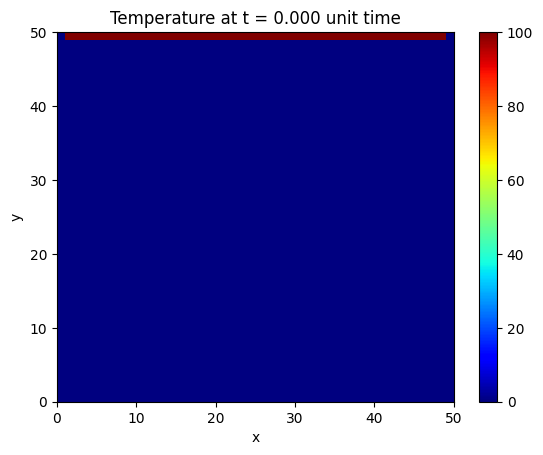

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.animation import FuncAnimation

print("2D heat equation solver")

plate_length = 50
max_iter_time = 750

alpha = 2
delta_x = 1

delta_t = (delta_x ** 2)/(4 * alpha)
gamma = (alpha * delta_t) / (delta_x ** 2)

# Initialize solution: the grid of u(k, i, j)
u = np.empty((max_iter_time, plate_length, plate_length))

# Initial condition everywhere inside the grid
u_initial = 0

# Boundary conditions
u_top = 100.0
u_left = 0.0
u_bottom = 0.0
u_right = 0.0

# Set the initial condition
u.fill(u_initial)

# Set the boundary conditions
u[:, (plate_length-1):, :] = u_top
u[:, :, :1] = u_left
u[:, :1, 1:] = u_bottom
u[:, :, (plate_length-1):] = u_right

def calculate(u):
    for k in range(0, max_iter_time-1, 1):
        for i in range(1, plate_length-1, delta_x):
            for j in range(1, plate_length-1, delta_x):
                u[k + 1, i, j] = gamma * (u[k][i+1][j] + u[k][i-1][j] + u[k][i][j+1] + u[k][i][j-1] - 4*u[k][i][j]) + u[k][i][j]

    return u

def plotheatmap(u_k, k):
    # Clear the current plot figure
    plt.clf()

    plt.title(f"Temperature at t = {k*delta_t:.3f} unit time")
    plt.xlabel("x")
    plt.ylabel("y")

    # This is to plot u_k (u at time-step k)
    plt.pcolormesh(u_k, cmap=plt.cm.jet, vmin=0, vmax=100)
    plt.colorbar()

    return plt

# Do the calculation here
u = calculate(u)

def animate(k):
    plotheatmap(u[k], k)

anim = animation.FuncAnimation(plt.figure(), animate, interval=1, frames=max_iter_time, repeat=False)
anim.save("heat_equation_solution.gif")

print("Done!")

Saving GIF... this may take a moment.
GIF Saved as 'stove_simulation.gif'


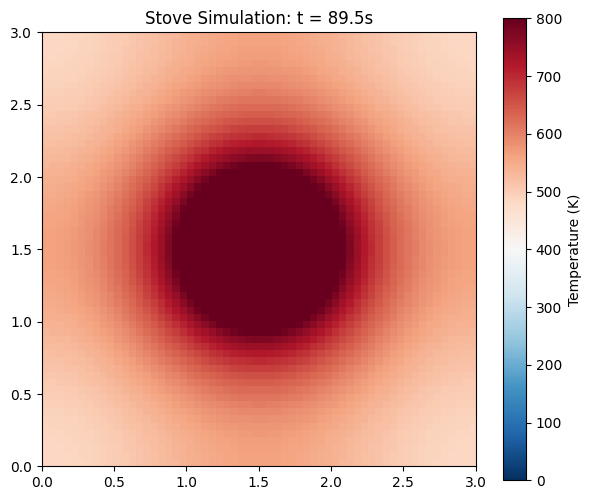

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from scipy import sparse
from scipy.sparse import linalg

# --- 1. Parameters ---
J = 60
L_grid = 3.0  
h = L_grid / J
s = np.linspace(0, L_grid, J)
xx, yy = np.meshgrid(s, s)

# Using a slightly higher alpha so the GIF looks "active" in 30s
z = 1
# alpha = 2.2e-5
alpha = 1e-2
# beta = 0.01
beta = 0
T_a = 293.15
r = 1
gamma = 200
sd = 0.1
k = 0.5        # Time step

# --- 2. Matrix Construction (Backward Euler) ---
N = J
e = np.ones(N)
L1d = sparse.spdiags([e, -2*e, e], [-1, 0, 1], N, N).tocsr()
L1d[0, 0], L1d[0, 1] = -2, 2      # Neumann (Insulated)
L1d[-1, -1], L1d[-1, -2] = -2, 2
L1d = (1 / h**2) * L1d

I1d = sparse.eye(N)
L = sparse.kron(I1d, L1d) + sparse.kron(L1d, I1d)
I = sparse.eye(J*J)

# Backward Euler Matrix: (I - k*alpha*L + k*beta*I)
A = (1 + k*beta) * I - k*alpha * L

# --- 3. Source Term (The Stove) ---
source = ((gamma) / (np.sqrt(2*np.pi)*sd)) * np.exp(-((xx-1.5)**2 + (yy-1.5)**2) / (2*sd**2))
source_flat = source.flatten()

# --- 4. Setup Plot ---
fig, ax = plt.subplots(figsize=(7, 6))
u = np.full((J*J,), T_a)
im = ax.imshow(u.reshape(J, J), extent=[0, 3, 0, 3], origin='lower', cmap='RdBu_r', vmin=0, vmax=1000)
plt.colorbar(im, label='Temperature (K)')
title = ax.set_title("Time t = 0.0s")

# --- 5. Animation Logic ---
def update(frame):
    global u
    # Solve Step
    b = u + k * source_flat
    u = linalg.spsolve(A, b)
    u = np.clip(u, T_a, 1200) # Safety clip
    
    # Update plot data
    im.set_array(u.reshape(J, J))
    title.set_text(f"Stove Simulation: t = {frame * k:.1f}s")
    return [im]

# Create animation object
# frames=60 with k=0.5 means a 30-second simulation
ani = FuncAnimation(fig, update, frames=180, interval=100, blit=True)

# --- 6. SAVE AS GIF ---
print("Saving GIF... this may take a moment.")
ani.save("stove_simulation.gif", writer='pillow', fps=10)
print("GIF Saved as 'stove_simulation.gif'")

plt.show()